In [2]:
# limit the thread used by numpy for better parallelization
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [4]:
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    print("no cupy ")

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.Cosmology import LuminosityDistance, z_dl
from Triangle.TDIFly import TDIFly

# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

# import multiprocessing
# if __name__ == "__main__":
#     multiprocessing.set_start_method("fork")
# print("number of cpus =", multiprocessing.cpu_count())
# pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())

no cupy 


In [ ]:
from phenomxpy.phenomt import PhenomT, PhenomTHM
from phenomxpy.utils import MasstoSecond, SecondtoMass, AmpNRtoSI, AmpSItoNR, ModeToString, SpinWeightedSphericalHarmonic
from phenomxpy.fft import SimInspiralChirpStartFrequencyBound
from phenomxpy.internals import Cache
from scipy.interpolate import CubicSpline

In [5]:
class TDIFlyMBHB(TDIFly):
    def __init__(self, orbit, Pstring, tcb_times, Nsparse=512, drop_points=0, use_gpu=False):
        super().__init__(orbit, Pstring, tcb_times, Nsparse, drop_points, use_gpu)

    def __call__(self, parameters, mode="primary", linear_interp=False):
        """ 
        Args: 
            parameters: a dictionary of source parameters, each item is a float number. NOTE that coa_phase is actually the initial phase 
            mode: "primary" for 22, "full" for all harmonics 
        """
        # convert parameters 
        m1 = m1_Mc_q(parameters["chirp_mass"], parameters["mass_ratio"]) # in MSUN 
        m2 = m1 * parameters["mass_ratio"] # in MSUN 
        M = m1 + m2 # in MSUN 
        buffered_Tobs_SI = 1.2 * self.Tobs 
        f_lower_SI = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN))
        wf_params = dict(
            delta_t_sec=10. * parameters["chirp_mass"] / 1e6, 
            # inclination=parameters["inclination"], 
            # phiRef=parameters["coalescence_phase"], 
            total_mass=M, 
            f_lower=f_lower_SI, 
            eta=eta_q(parameters["mass_ratio"]), 
            s1=[0., 0., parameters["spin_1z"]], 
            s2=[0., 0., parameters["spin_2z"]], 
            f_ref=None # i.e. f_ref = f_lower 
        )
        for k, v in wf_params.items(): # TEST 
            print(k, ":", v)
            
        # initialize phenomT waveform 
        if mode == "primary":
            phenT = PhenomTHM(
                **wf_params, 
                mode_array=[[2,2], [2,-2]],
                cuda=False, 
                numba_ansatzaes=False, 
                )
        elif mode == "full":
            phenT = PhenomTHM(
                **wf_params, 
                # mode_array=[[2,2], [2,-2]],
                cuda=False, 
                numba_ansatzaes=False, 
                )
        print("modes:", phenT.mode_array) # TEST 
        print("phenT_class modes:", phenT.phenT_classes.keys())
            
        # adaptive time grid 
        buffered_Tobs_SI *= -1. 
        interp_idx = self.xp.where(phenT.times > -200.)[0]
        wf_time_SI = MasstoSecond(phenT.times[interp_idx], M)
        wf_22_phase = phenT.phenT_classes["22"].pPhase.full_phase(times=phenT.times[interp_idx])
        delta_Phi = 0.5
        K = 1.1
        delta_t_threshold_SI = 2e5   
        Phi_c = wf_22_phase[-1]

        max_time_sample_idx1 = int((Phi_c - phenT.phenT_classes["22"].pPhase.full_phase(times=-100.)) / delta_Phi) 
        time_sample_idx1 = self.xp.arange(max_time_sample_idx1 + 1)
        time_sample1_SI = self.xp.interp(
            x = Phi_c - delta_Phi * (max_time_sample_idx1 - time_sample_idx1), 
            xp = wf_22_phase, 
            fp = wf_time_SI, 
        )
        # print("number of time samples in the 1st segment:", max_time_sample_idx1)

        if time_sample1_SI[0] > buffered_Tobs_SI:
        #     min_delta_t_SI = time_sample1_SI[1] - time_sample1_SI[0]
        #     a_coef = 1. / np.log(K)
        #     b_coef = np.log(min_delta_t_SI) * a_coef
        #     max_time_sample_idx2 = int((np.log(delta_t_threshold_SI / min_delta_t_SI)))
        #     time_sample_idx2 = np.arange(max_time_sample_idx2 + 1)
        #     time_sample2_SI = (time_sample1_SI[0] - np.power(K, a_coef * time_sample_idx2 + b_coef))[::-1]
        #     # print("number of time samples in the 2nd segment:", max_time_sample_idx2)
            
        #     if time_sample2_SI[0] > buffered_Tobs_SI:
        #         time_sample3_SI = self.xp.arange(buffered_Tobs_SI, time_sample2_SI[0], delta_t_threshold_SI)
        #         # print("number of time samples in the 3rd segment:", len(time_sample3_SI))
        #         time_samples_SI = self.xp.concatenate((time_sample3_SI, time_sample2_SI, time_sample1_SI))
        #         # print("total time sample shape:", len(time_samples_SI))
                
        #     else: 
        #         time_samples_SI = self.xp.concatenate((time_sample2_SI[time_sample2_SI>=buffered_Tobs_SI], time_sample1_SI))
            
        # else: 
        #     time_samples_SI = time_sample1_SI[time_sample1_SI>=buffered_Tobs_SI]
        
            time_sample2_SI = self.xp.linspace(buffered_Tobs_SI, time_sample1_SI[0], 256, endpoint=False)
            time_samples_SI = self.xp.concatenate((time_sample2_SI, time_sample1_SI))
        
        # convert time grids between SI and NR unit 
        self.Nsample = len(time_samples_SI) # number of sparse sample points 
        print("number of samples:", self.Nsample) # TEST 
        orbit_time_samples_SI = time_samples_SI + parameters["coalescence_time"] * DAY 
        time_samples_Mass = SecondtoMass(time_samples_SI, M)

        # external parameters 
        longitude = parameters["longitude"]
        latitude = parameters["latitude"]
        psi = parameters["psi"]
        
        # wave vectors
        k = -self.xp.array([self.COS(latitude) * self.COS(longitude), self.COS(latitude) * self.SIN(longitude), self.SIN(latitude)]) # (3)
        u = self.xp.array([self.SIN(longitude), -self.COS(longitude), 0.]) # (3)
        v = self.xp.array([-self.SIN(latitude) * self.COS(longitude), -self.SIN(latitude) * self.SIN(longitude), self.COS(latitude)]) # (3)
        
        # arm projections 
        n12 = self.xp.array([
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["12"][:, 0]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["12"][:, 1]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["12"][:, 2]), 
            ]).T # (Nsample, 3)
        n23 = self.xp.array([
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["23"][:, 0]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["23"][:, 1]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["23"][:, 2]), 
            ]).T # (Nsample, 3)
        n31 = self.xp.array([
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["31"][:, 0]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["31"][:, 1]), 
            self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.arm_vector_dict["31"][:, 2]), 
            ]).T # (Nsample, 3)
        un12 = self.MATMUL(n12, u) # (Nsample)
        un23 = self.MATMUL(n23, u)
        un31 = self.MATMUL(n31, u)
        vn12 = self.MATMUL(n12, v) 
        vn23 = self.MATMUL(n23, v)
        vn31 = self.MATMUL(n31, v)
        
        # pattern functions in the SSB frame 
        xiplus12 = un12 ** 2 - vn12 ** 2 # (Nsample), xi_ij = xi_ji
        xiplus23 = un23 ** 2 - vn23 ** 2
        xiplus31 = un31 ** 2 - vn31 ** 2
        xicross12 = 2. * un12 * vn12
        xicross23 = 2. * un23 * vn23
        xicross31 = 2. * un31 * vn31 
        
        # pattern functions in the source frame 
        cos2psi = self.COS(2. * psi) # (1)
        sin2psi = self.SIN(2. * psi)
        zetaplus12 = cos2psi * xiplus12 + sin2psi * xicross12 # (Nsample)
        zetaplus23 = cos2psi * xiplus23 + sin2psi * xicross23
        zetaplus31 = cos2psi * xiplus31 + sin2psi * xicross31 
        zetacross12 = -sin2psi * xiplus12 + cos2psi * xicross12
        zetacross23 = -sin2psi * xiplus23 + cos2psi * xicross23
        zetacross31 = -sin2psi * xiplus31 + cos2psi * xicross31 
        zetaplus = {
                "12": zetaplus12,  # (Nsample)
                "23": zetaplus23, 
                "31": zetaplus31, 
                "21": zetaplus12, 
                "32": zetaplus23, 
                "13": zetaplus31 
            }
        zetacross = {
                "12": zetacross12, 
                "23": zetacross23, 
                "31": zetacross31, 
                "21": zetacross12, 
                "32": zetacross23, 
                "13": zetacross31 
            }
        
        # the knij terms 
        kn = {
            "12": self.MATMUL(n12, k), # (Nsample)
            "23": self.MATMUL(n23, k), 
            "31": self.MATMUL(n31, k), 
            "21": -self.MATMUL(n12, k), 
            "32": -self.MATMUL(n23, k), 
            "13": -self.MATMUL(n31, k), 
        }
        
        # # the dij terms 
        # delay_ij = {mosa: self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.dij_dict[mosa]) for mosa in MOSA_labels} # each item (Nsample)
        
        # # the Ri terms 
        # pos_i = {
        #     sc: self.xp.array([
        #         self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.sc_position_vector_dict[sc][:, 0]), 
        #         self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.sc_position_vector_dict[sc][:, 1]), 
        #         self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=self.sc_position_vector_dict[sc][:, 2]), 
        #         ]).T for sc in SC_labels
        # } # each item (Nsample, 3)
        
        # combine the sparse TDI response 
        self.tdi_responses_mode = {ModeToString(mode): [] for mode in phenT.mode_array} # each item (Nchannel, Ntime)
        tdi_response_total = self.xp.zeros((self.Nchannel, self.Ntime), dtype=self.xp.float64)
        print("form of return dict:", self.tdi_responses_mode) # TEST 
        for mode in phenT.mode_array:
            mode_str = ModeToString(mode)
            mode_absm_str = str(mode[0])+str(self.xp.abs(mode[1]))
            print("lm and l|m| mode strs:", mode_str, mode_absm_str) # TEST 
            ll = mode[0]
            mm = mode[1]
            amp_global_factor = self.xp.sign(mm) ** ll 
            phase_global_factor = self.xp.sign(mm) # only applied to total phase 
            print("amp and phase overall factors:", amp_global_factor, phase_global_factor)
            Ylm = SpinWeightedSphericalHarmonic(parameters["inclination"], np.pi / 2 - parameters["coalescence_phase"], ll, mm) # mm can be negative 
            
            # amplitude and phase for l|m| mode 
            pamp_obj_lm = phenT.phenT_classes[mode_absm_str].pAmp # amplitude object of l|m| mode 
            pphase_obj_lm = phenT.phenT_classes[mode_absm_str].pPhase # phase object of l|m| mode 
            phase_offset_lm = - pphase_obj_lm.phoff - pphase_obj_lm.phiref0 * self.xp.abs(mm) / 2.0
            print("phase offset:", pphase_obj_lm.phoff) # TEST 
            print("phase emm:", pphase_obj_lm.phiref0 * self.xp.abs(mm) / 2.0) # TEST 
            phase_nooffset_lm = pphase_obj_lm.full_phase(times=time_samples_Mass) # (Nsample)
            phase_lm = (phase_nooffset_lm + phase_offset_lm) * phase_global_factor  # (Nsample)
            
            for ichannel in range(self.Nchannel):
                sparse_response = self.xp.zeros(self.Nsample, dtype=self.xp.complex128)
                for mosa in MOSA_labels: 
                    if self.Ndelay_dict[ichannel][mosa] == 0: 
                        continue
                    else: 
                        Denominator_term = 0.5 / (1. - kn[mosa]) # (Nsample)
                        Pattern_term = zetaplus[mosa] - 1.j * zetacross[mosa] # (Nsample), complex 
                        Phase_delay_term = self.xp.zeros((self.Nsample), dtype=self.xp.complex128)
                        for Idelay in range(self.Ndelay_dict[ichannel][mosa]):
                            d_em_0 = self.delay_dict[ichannel][mosa][Idelay] + self.delayed_dij_dict[ichannel][mosa][Idelay] + self.MATMUL(self.delayed_send_position_vector_dict[ichannel][mosa][Idelay], k) / C # (Nsparse)
                            d_re_0 = self.delay_dict[ichannel][mosa][Idelay] + self.MATMUL(self.delayed_recv_position_vector_dict[ichannel][mosa][Idelay], k) / C # (Nsparse)
                            d_em = self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=d_em_0) # (Nsample)
                            d_re = self.xp.interp(x=orbit_time_samples_SI, xp=self.sparse_times, fp=d_re_0) # (Nsample)
                            delayed_time_em_mass = SecondtoMass(time_samples_SI - d_em, M)
                            delayed_time_re_mass = SecondtoMass(time_samples_SI - d_re, M)
                            dphi_em = (pphase_obj_lm.full_phase(times=delayed_time_em_mass) - phase_nooffset_lm) * phase_global_factor # (Nsample)
                            dphi_re = (pphase_obj_lm.full_phase(times=delayed_time_re_mass) - phase_nooffset_lm) * phase_global_factor # (Nsample)
                            if mode_absm_str == "22":
                                amp_em = self.xp.abs(pamp_obj_lm.full_amplitude(times=delayed_time_em_mass)) * amp_global_factor # (Nsample)
                                amp_re = self.xp.abs(pamp_obj_lm.full_amplitude(times=delayed_time_re_mass)) * amp_global_factor # (Nsample) 
                            else:                         
                                amp_em = pamp_obj_lm.full_amplitude(times=delayed_time_em_mass) * amp_global_factor # (Nsample)
                                amp_re = pamp_obj_lm.full_amplitude(times=delayed_time_re_mass) * amp_global_factor # (Nsample)
                            # print("abs mode:", mode_absm_str) # TEST 
                            # print("amplitudes:",amp_re) # TEST 
                            Phase_delay_term += self.delay_factor_dict[ichannel][mosa][Idelay] * (amp_em * self.EXP(-1.j * dphi_em) - amp_re * self.EXP(-1.j * dphi_re)) # (Nsample)
                        sparse_response += Denominator_term * Pattern_term * Phase_delay_term # (Nsample) sum over mosas is completed 
                
                # get the amplitude and phase of response 
                sparse_response *= Ylm 
                sparse_amp = self.xp.abs(sparse_response) # (Nsample)
                sparse_phase = self.xp.unwrap(self.xp.angle(sparse_response)) - phase_lm # unwrap to ensure continuity (Nsample)
                # plt.semilogy(orbit_time_samples_SI, sparse_amp, label=mode_str) # TEST 
                # plt.plot(orbit_time_samples_SI, sparse_phase, label=mode_str) # TEST 
                
                # calculate tdi variable at full sampling rate 
                if linear_interp:
                    full_amp = self.xp.interp(x=self.tcb_times, xp=orbit_time_samples_SI, fp=sparse_amp) # (Ntime)
                    full_phase = self.xp.interp(x=self.tcb_times, xp=orbit_time_samples_SI, fp=sparse_phase) # (Ntime)
                else:
                    full_amp_func = CubicSpline(
                        x=orbit_time_samples_SI,
                        y=sparse_amp, 
                        extrapolate=False 
                    )
                    full_amp = self.xp.nan_to_num(full_amp_func(self.tcb_times), nan=0.) # (Ntime)
                    full_phase_func = CubicSpline(
                        x=orbit_time_samples_SI,
                        y=sparse_phase, 
                        extrapolate=False 
                    )
                    full_phase = self.xp.nan_to_num(full_phase_func(self.tcb_times), nan=0.) # (Ntime)
                # plt.semilogy(self.tcb_times, full_amp, label=mode_str) # TEST 
                
                res = AmpNRtoSI(
                    self.xp.real(full_amp * self.EXP(1.j * full_phase)), 
                    distance=parameters["luminosity_distance"],
                    total_mass=M, 
                    ) # (Ntime) this is the response for lm mode and i-th channel, converted to SI unit 
                
                self.tdi_responses_mode[ModeToString(mode)].append(res) # append to channels 
                tdi_response_total[ichannel] += res # sum over modes 
            # plt.legend() # TEST 
        return tdi_response_total

In [6]:
class MBHB_Injection_PhenT:
    def __init__(self, mode="primary", internal_time=False, use_gpu=False):
        if mode=="primary":
            self.mode_array = [[2,2],[2,-2]]
            self.max_m = 2. 
        elif mode == "full": 
            self.mode_array = None 
            self.max_m = 5. 
        else: 
            raise ValueError("mode not supported.")
        self.internal_time = internal_time
        self.use_gpu=use_gpu

    def __call__(self, parameters, times):
        # convert parameters 
        m1 = m1_Mc_q(parameters["chirp_mass"], parameters["mass_ratio"]) # in MSUN 
        m2 = m1 * parameters["mass_ratio"] # in MSUN 
        M = m1 + m2 # in MSUN 
        Tobs = times[-1] - times[0]
        buffered_Tobs_SI = 1.2 * Tobs 
        f_lower_SI = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN))
        self.wf_dt=10. * parameters["chirp_mass"] / 1e6 * 5. / self.max_m 
        wf_params = dict(
            delta_t_sec = self.wf_dt, 
            total_mass=M, 
            f_lower=f_lower_SI, 
            eta=eta_q(parameters["mass_ratio"]), 
            s1=[0., 0., parameters["spin_1z"]], 
            s2=[0., 0., parameters["spin_2z"]], 
            f_ref=None # i.e. f_ref = f_lower 
        )
            
        # initialize phenomT waveform 
        phenT = PhenomTHM(
            **wf_params, 
            mode_array=self.mode_array,
            cuda=self.use_gpu, 
            numba_ansatzaes=False, 
            )
        
        # calculate polarizations 
        if self.internal_time:
            self.wf_times_SI = MasstoSecond(phenT.times, M) + parameters["coalescence_time"] * DAY
            self.hp, self.hc = phenT.compute_polarizations(
                inclination=parameters["inclination"], 
                phiRef=parameters["coalescence_phase"], 
                times=None, 
                distance=parameters["luminosity_distance"], 
                total_mass=M, 
            )
        else: 
            self.wf_times_SI = times 
            self.hp, self.hc = phenT.compute_polarizations(
                inclination=parameters["inclination"], 
                phiRef=parameters["coalescence_phase"], 
                times=SecondtoMass(times - parameters["coalescence_time"] * DAY, M), 
                distance=parameters["luminosity_distance"], 
                total_mass=M, 
            )
        # print("number of time points:", len(wf_times_SI))

        return self.wf_times_SI, self.hp + 1.0j * self.hc 

## Settings 

In [7]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = 15.*DAY
Mcz = 1e6
dt = 10. * Mcz / 1e6 
tcb_times = np.arange(int(Tobs / dt)) * dt

In [8]:
MBHB_params = {
    'chirp_mass': Mcz, 
    'coalescence_phase': 4.618102360940744,
    'coalescence_time': Tobs/DAY-1.,
    'inclination': 1.8709099988987916,
    'latitude': -0.6806154941973864,
    'longitude': 2.8373429551400404,
    'luminosity_distance': 13931.62935982271,
    'mass_ratio': 0.6800360995621981,
    'psi': 1.6782894010201774,
    'spin_1z': -0.39382065863038396,
    'spin_2z': 0.8223863508989862
    }
MBHB_params

{'chirp_mass': 1000000.0,
 'coalescence_phase': 4.618102360940744,
 'coalescence_time': 14.0,
 'inclination': 1.8709099988987916,
 'latitude': -0.6806154941973864,
 'longitude': 2.8373429551400404,
 'luminosity_distance': 13931.62935982271,
 'mass_ratio': 0.6800360995621981,
 'psi': 1.6782894010201774,
 'spin_1z': -0.39382065863038396,
 'spin_2z': 0.8223863508989862}

In [9]:
tdifly = TDIFlyMBHB(
    orbit=orbit, 
    Pstring=[TDIFly.X2_strings,], 
    tcb_times=tcb_times, 
    Nsparse=512, 
)



In [10]:
x2_tdifly_cubic = tdifly(
    parameters=MBHB_params, 
    linear_interp=False
    )

delta_t_sec : 10.0
total_mass : 2348892.57874874
f_lower : 0.00012796539758280708
eta : 0.24093214126191492
s1 : [0.0, 0.0, -0.39382065863038396]
s2 : [0.0, 0.0, 0.8223863508989862]
f_ref : None
modes: [[2, 2], [2, -2]]
phenT_class modes: dict_keys(['22'])
number of samples: 823
form of return dict: {'22': [], '2-2': []}
lm and l|m| mode strs: 22 22
amp and phase overall factors: 1 1
phase offset: 0
phase emm: -1953.0062496283554
lm and l|m| mode strs: 2-2 22
amp and phase overall factors: 1 -1
phase offset: 0
phase emm: -1953.0062496283554


In [11]:
# mode="primary"
mode="full"

mbhb_waveform_generator = MBHB_Injection_PhenT(
    mode=mode, 
    internal_time=False, 
)
mbhb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    interp_method="Spline5",
)
for _ in tqdm(range(10)):
    x2_fastmich_noint_5 = mbhb_response_generator(parameters=MBHB_params, waveform_generator=mbhb_waveform_generator,optimal_combination=False)

mbhb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    interp_method="Spline3",
    # interp_method="linear",
)
for _ in tqdm(range(10)):
    x2_fastmich_noint_3 = mbhb_response_generator(parameters=MBHB_params, waveform_generator=mbhb_waveform_generator,optimal_combination=False)

mbhb_waveform_generator = MBHB_Injection_PhenT(
    mode=mode, 
    internal_time=True, 
)
mbhb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    interp_method="Spline5",
)
for _ in tqdm(range(10)):
    x2_fastmich_int_5 = mbhb_response_generator(parameters=MBHB_params, waveform_generator=mbhb_waveform_generator,optimal_combination=False)
mbhb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    interp_method="Spline3",
    # interp_method="linear"
)
for _ in tqdm(range(10)):
    x2_fastmich_int_3 = mbhb_response_generator(parameters=MBHB_params, waveform_generator=mbhb_waveform_generator,optimal_combination=False)

100%|██████████| 10/10 [00:03<00:00,  2.76it/s]


In [12]:
mbhb_waveform_generator.wf_dt, dt

(10.0, 10.0)

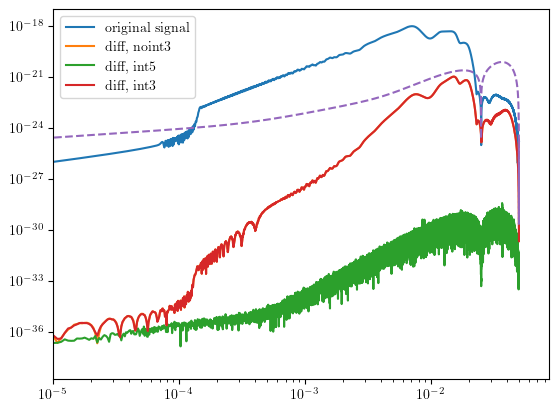

In [18]:
ff, xf1 = FFT_window(x2_fastmich_noint_5[0], 1./dt)
plt.loglog(ff, np.abs(xf1)*2.*ff, label="original signal")
ff, xf2 = FFT_window(x2_fastmich_noint_3[0], 1./dt)
plt.loglog(ff, np.abs(xf1-xf2)*2.*ff, label="diff, noint3")
ff, xf3 = FFT_window(x2_fastmich_int_5[0], 1./dt)
plt.loglog(ff, np.abs(xf1-xf3)*2.*ff, label="diff, int5")
ff, xf4 = FFT_window(x2_fastmich_int_3[0], 1./dt)
plt.loglog(ff, np.abs(xf1-xf4)*2.*ff, label="diff, int3")
PSDfunc=TDIPSDs()
plt.loglog(ff, np.sqrt(PSDfunc.PSD_X2(ff)*ff), linestyle="--")
plt.xlim(1e-5,)
# plt.ylim(1e-27,)
plt.legend(loc="upper left")

(1199600.0, 1219600.0)

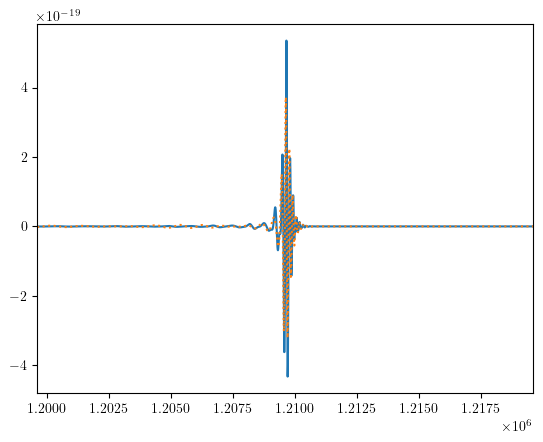

In [14]:
plt.plot(tcb_times, x2_fastmich_noint_5[0])
plt.plot(tcb_times, x2_tdifly_cubic[0], linestyle=":")

plt.xlim(MBHB_params["coalescence_time"]*DAY-10000, MBHB_params["coalescence_time"]*DAY+10000)
# plt.ylim(-1e-21, 1e-21)

(1e-23, 3.489753758113234e-18)

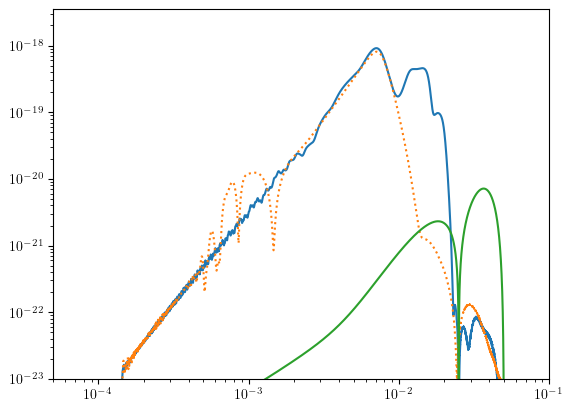

In [15]:
ff, xf1 = FFT_window(x2_fastmich_noint_5[0], 1./dt)
plt.loglog(ff, np.abs(xf1)*2.*ff)
ff, xf2 = FFT_window(x2_tdifly_cubic[0], 1./dt)
plt.loglog(ff, np.abs(xf2)*2.*ff, linestyle=":")
# plt.loglog(ff, np.abs(xf1 - xf2)*2.*ff)
PSDfunc = TDIPSDs()
plt.loglog(ff, np.sqrt(PSDfunc.PSD_X2(ff)*ff))
plt.xlim(5e-5, 0.1)
plt.ylim(1e-23,)

In [16]:
mbhb_waveform_generator.wf_times_SI/DAY, mbhb_waveform_generator.

SyntaxError: invalid syntax (12410026.py, line 1)

## Initialize response models 

### TDI-on-the-fly

In [ ]:
fast_response_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring=TDIFlyGB.X2_strings, 
    tcb_times=tcb_times.copy(), 
    Nsparse=1024, 
    # Nsparse=512,
    drop_points=1000, 
    use_gpu=False, 
)



NameError: name 'TDIFlyGB' is not defined

### general TDI response 

In [ ]:
gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=TDIFlyGB.X2_strings, 
    tcb_times=tcb_times.copy(), 
    use_gpu=False, 
    drop_points=1000,
    linear_interp=False, 
    return_eta=False, 
)

KeyboardInterrupt: 